In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ============================================================
# OU Setting
# x0 ~ N(10, 2)
# dX_t = - beta X_t dt + sigma dW_t
# ============================================================

mu0 = 10.0
var0 = 2.0
std0 = np.sqrt(var0)

beta = 1.0
T = 5.0

N = 10000

sigmas = [
    0.5,
    1.0,
    np.sqrt(2 * beta),
    2.0,
    3.0
]

eps_t = 0.05

def ou_marginal_params(t, sigma):
    a_t = np.exp(-beta * t)

    cond_var_t = (
        sigma**2 / (2 * beta)
        * (1 - np.exp(-2 * beta * t))
    )

    mu_t = a_t * mu0

    var_t = (
        (a_t**2) * var0
        + cond_var_t
    )

    return a_t, cond_var_t, mu_t, var_t

In [3]:
# ============================================================
# Score Network
# ============================================================

class ScoreNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(2, 64),
            nn.SiLU(),

            nn.Linear(64, 64),
            nn.SiLU(),

            nn.Linear(64, 1)

        )

    def forward(self, x, t):

        inp = torch.cat([x, t], dim=1)

        return self.net(inp)

# ============================================================
# build model
# ============================================================

def build_model():

    model = ScoreNet()

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    return model, optimizer
model, optimizer = build_model()

In [4]:
# ============================================================
# Train one OU score model for a given sigma
# ============================================================

def train_ou_model(sigma, epochs=5000, batch_size=2048):

    model, optimizer = build_model()

    L_ESM_history = []
    L_ISM_history = []
    L_DSM_history = []
    I_DSM_history = []

    for epoch in range(epochs):

        # sample x0
        x0 = torch.randn(batch_size, 1) * np.sqrt(var0) + mu0

        # sample t ~ Uniform(eps_t, T)
        t_batch = eps_t + (T - eps_t) * torch.rand(batch_size, 1)

        # OU coefficients
        a_t = torch.exp(-beta * t_batch)

        cond_var_t = (
            sigma**2 / (2 * beta)
            * (1 - torch.exp(-2 * beta * t_batch))
        )

        cond_std_t = torch.sqrt(cond_var_t)

        # generate xt
        eps = torch.randn_like(x0)

        xt = a_t * x0 + cond_std_t * eps
        xt.requires_grad_(True)

        # marginal p_t(x)
        mu_t = a_t * mu0
        var_t = (a_t**2) * var0 + cond_var_t

        # exact marginal score
        score_t = -(xt - mu_t) / var_t

        # conditional score
        cond_score = -(xt - a_t * x0) / cond_var_t

        # network prediction
        pred_score = model(xt, t_batch)

        # L_ESM
        L_ESM = ((pred_score - score_t) ** 2).mean()

        # L_ISM
        div_score = torch.autograd.grad(
            outputs=pred_score.sum(),
            inputs=xt,
            create_graph=True
        )[0]

        L_ISM = (pred_score**2 + 2 * div_score).mean()

        # L_DSM
        term1 = (score_t**2).mean()
        term2 = (cond_score**2).mean()

        L_DSM = L_ESM - term1 + term2

        # I_DSM
        I_DSM = (
            pred_score**2
            - pred_score * cond_score
        ).mean()

        # train
        optimizer.zero_grad()
        L_ESM.backward()
        optimizer.step()

        # record
        L_ESM_history.append(L_ESM.item())
        L_ISM_history.append(L_ISM.item())
        L_DSM_history.append(L_DSM.item())
        I_DSM_history.append(I_DSM.item())

        if epoch % 500 == 0:
            print(
                f"sigma = {sigma:.3f} | "
                f"Epoch {epoch:4d} | "
                f"L_ESM = {L_ESM.item():.8f} | "
                f"L_ISM = {L_ISM.item():.8f} | "
                f"L_DSM = {L_DSM.item():.8f} | "
                f"I_DSM = {I_DSM.item():.8f}"
            )

    return model, {
        "L_ESM": L_ESM_history,
        "L_ISM": L_ISM_history,
        "L_DSM": L_DSM_history,
        "I_DSM": I_DSM_history,
    }

In [5]:
models = {}
histories = {}

for sigma in sigmas:
    print(f"\n========== Training sigma = {sigma:.3f} ==========")

    model, history = train_ou_model(
        sigma=sigma,
        epochs=5000,
        batch_size=2048
    )

    models[float(sigma)] = model
    histories[float(sigma)] = history


========== Training sigma = 0.500 ==========
sigma = 0.500 | Epoch    0 | L_ESM = 5.79520559 | L_ISM = 0.07317407 | L_DSM = 10.64168930 | I_DSM = 0.04504198
sigma = 0.500 | Epoch  500 | L_ESM = 0.03472570 | L_ISM = -5.82390642 | L_DSM = 3.95385027 | I_DSM = -0.01999794
sigma = 0.500 | Epoch 1000 | L_ESM = 0.01107921 | L_ISM = -5.59045506 | L_DSM = 3.90445185 | I_DSM = 0.03125094
sigma = 0.500 | Epoch 1500 | L_ESM = 0.00350488 | L_ISM = -5.93834496 | L_DSM = 3.91964245 | I_DSM = -0.07439024
sigma = 0.500 | Epoch 2000 | L_ESM = 0.00571673 | L_ISM = -5.86133862 | L_DSM = 4.49175119 | I_DSM = 0.02859134
sigma = 0.500 | Epoch 2500 | L_ESM = 0.00144696 | L_ISM = -5.42921114 | L_DSM = 4.49447775 | I_DSM = -0.01461966
sigma = 0.500 | Epoch 3000 | L_ESM = 0.00117663 | L_ISM = -5.82424688 | L_DSM = 2.86297417 | I_DSM = 0.05161971
sigma = 0.500 | Epoch 3500 | L_ESM = 0.00232803 | L_ISM = -5.57096291 | L_DSM = 4.09752560 | I_DSM = -0.06961142
sigma = 0.500 | Epoch 4000 | L_ESM = 0.00051404 | L_IS

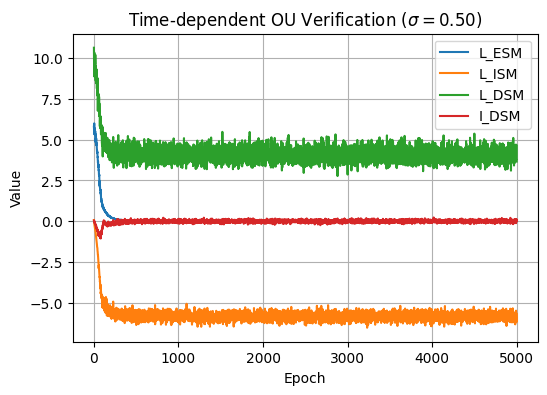

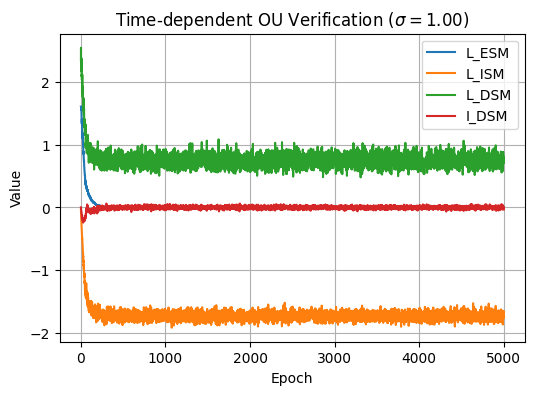

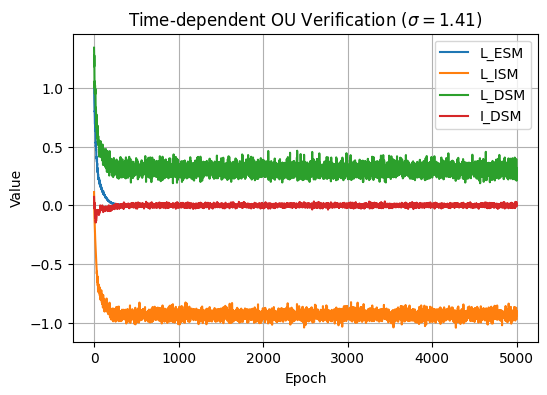

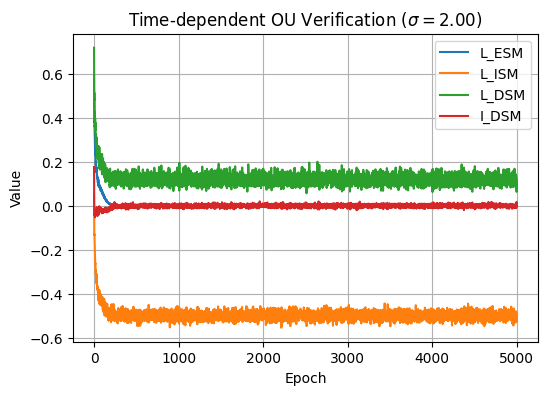

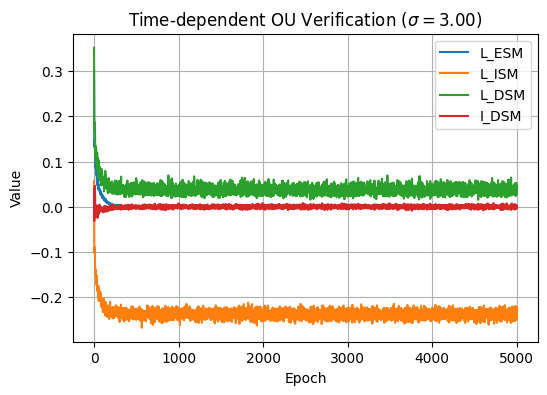

In [6]:
# ============================================================
# Plot OU losses for different sigmas
# ============================================================

for sigma in sigmas:

    history = histories[float(sigma)]

    plt.figure(figsize=(6,4))

    plt.plot(
        history["L_ESM"],
        label='L_ESM'
    )

    plt.plot(
        history["L_ISM"],
        label='L_ISM'
    )

    plt.plot(
        history["L_DSM"],
        label='L_DSM'
    )

    plt.plot(
        history["I_DSM"],
        label='I_DSM'
    )

    plt.xlabel("Epoch")
    plt.ylabel("Value")

    plt.title(
        rf"Time-dependent OU Verification ($\sigma={sigma:.2f}$)"
    )

    plt.legend()
    plt.grid(True)

    plt.show()

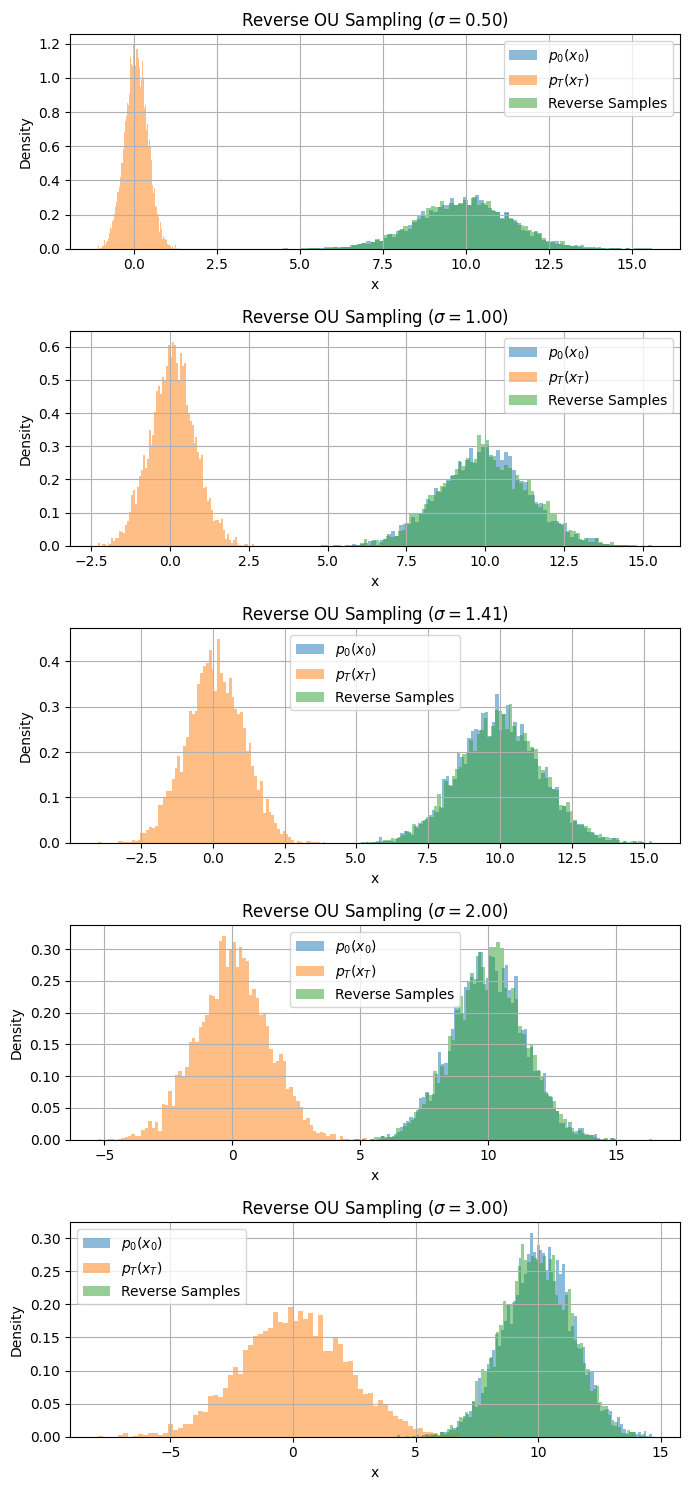

In [9]:
# ============================================================
# Reverse OU Sampling for different sigmas
# ============================================================

fig, axes = plt.subplots(
    len(sigmas),
    1,
    figsize=(7, 3 * len(sigmas))
)

num_samples = 5000
steps = 1000

for idx, sigma in enumerate(sigmas):

    sigma = float(sigma)

    model = models[sigma]

    dt = (T - eps_t) / steps

    # ========================================================
    # p_T parameters
    # ========================================================

    a_T = np.exp(-beta * T)

    cond_var_T = (
        sigma**2 / (2 * beta)
        * (1 - np.exp(-2 * beta * T))
    )

    mu_T = a_T * mu0

    var_T = (
        (a_T**2) * var0
        + cond_var_T
    )

    # start from p_T
    x = (
        torch.randn(num_samples, 1)
        * np.sqrt(var_T)
        + mu_T
    )

    # ========================================================
    # reverse SDE
    # ========================================================

    model.eval()

    with torch.no_grad():

        for i in range(steps):

            t_now = T - i * dt

            t_tensor = torch.ones_like(x) * t_now

            score = model(x, t_tensor)

            noise = torch.randn_like(x)

            x = (
                x
                + (beta * x + sigma**2 * score) * dt
                + sigma * np.sqrt(dt) * noise
            )

    x_eps = x

    # ========================================================
    # posterior sampling x0 | x_eps
    # ========================================================

    a_eps = np.exp(-beta * eps_t)

    cond_var_eps = (
        sigma**2 / (2 * beta)
        * (1 - np.exp(-2 * beta * eps_t))
    )

    mu_eps = a_eps * mu0

    var_eps = (
        (a_eps**2) * var0
        + cond_var_eps
    )

    post_mean = (
        mu0
        + (a_eps * var0 / var_eps)
        * (x_eps - mu_eps)
    )

    post_var = (
        var0
        - (a_eps**2 * var0**2) / var_eps
    )

    x0_reverse = (
        post_mean
        + torch.sqrt(torch.tensor(post_var))
        * torch.randn_like(post_mean)
    )

    samples_reverse = (
        x0_reverse.cpu().numpy().flatten()
    )

    # ========================================================
    # true distributions
    # ========================================================

    x0_true = np.random.normal(
        mu0,
        np.sqrt(var0),
        num_samples
    )

    xT_true = np.random.normal(
        mu_T,
        np.sqrt(var_T),
        num_samples
    )

    # ========================================================
    # plot
    # ========================================================

    ax = axes[idx]

    ax.hist(
        x0_true,
        bins=80,
        density=True,
        alpha=0.5,
        label=r'$p_0(x_0)$'
    )

    ax.hist(
        xT_true,
        bins=80,
        density=True,
        alpha=0.5,
        label=r'$p_T(x_T)$'
    )

    ax.hist(
        samples_reverse,
        bins=80,
        density=True,
        alpha=0.5,
        label='Reverse Samples'
    )

    ax.set_title(
        rf'Reverse OU Sampling ($\sigma={sigma:.2f}$)'
    )

    ax.set_xlabel("x")
    ax.set_ylabel("Density")

    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()